# 05-Graph Compilation & Execution (ONNX Runtime)

In the first half of this section, we aggressively optimized hyperparameter search and neural architectures to find the most accurate mathematical models. However, an accurate model written in Python is often an operational liability.

Python is fundamentally slow. It is an interpreted language bound by the Global Interpreter Lock (GIL). When you deploy a PyTorch model behind a FastAPI endpoint, every inference request pays a massive "Python Tax"—the overhead of the interpreter dynamically dispatching C++ kernels one by one.

To engineer high-throughput, low-latency Enterprise MLOps, we must completely decouple our trained models from the Python ecosystem. We achieve this using **ONNX (Open Neural Network Exchange)**. In this module, we will mathematically compile a dynamic PyTorch model into a static computation graph and execute it using the **ONNX Runtime (ORT)** C++ engine, achieving massive latency reductions with zero loss in accuracy.

## 1. The Mathematics of Computation Graphs & Operator Fusion

### The Dynamic Graph (PyTorch)

Deep learning models are Directed Acyclic Graphs (DAGs) of mathematical operators. In PyTorch, this graph is built dynamically at runtime (*Define-by-Run*).
Let an input tensor $\mathbf{X}$ pass through a Linear layer followed by a ReLU activation:


$$\mathbf{H} = \mathbf{W} \mathbf{X} + \mathbf{b}$$

$$\mathbf{Y} = \max(0, \mathbf{H})$$


In PyTorch, the interpreter dispatches the Matrix Multiplication kernel, writes the intermediate tensor $\mathbf{H}$ to GPU/CPU memory, reads it back, dispatches the ReLU kernel, and writes $\mathbf{Y}$. This memory I/O bottleneck destroys inference speed.

### The Static Graph (ONNX)

ONNX is an open standard that captures this DAG as a strictly typed, language-agnostic protobuf file. Once the graph is static, the ONNX Runtime applies **Graph Optimization Calculus** before execution.

#### Mathematical Operator Fusion

The most critical optimization is Operator Fusion. Because the ONNX graph is static, the compiler sees the entire topological layout in advance. It mathematically recognizes that $\mathbf{H}$ is never requested by the user; it is only a temporary bridge to $\mathbf{Y}$.

The compiler dynamically writes a custom C++ kernel to fuse the operators:


$$\mathbf{Y} = \text{FusedLinearReLU}(\mathbf{X}, \mathbf{W}, \mathbf{b}) = \max(0, \mathbf{W} \mathbf{X} + \mathbf{b})$$


This mathematically eliminates the intermediate memory write/read cycle. The data remains in the ultra-fast L1 CPU/GPU cache, drastically reducing wall-clock latency.

## 2. Imperative Execution: Compiling PyTorch to ONNX

We will build a local PyTorch Neural Network, train it briefly, and then use `torch.onnx.export` to trace the mathematical execution path, compiling the dynamic Python object into a static, cross-platform `.onnx` binary.

In [2]:
# Required installations: pip install torch onnx onnxruntime numpy
import torch
import torch.nn as nn
import numpy as np
import time

print("--- 🚀 Initializing Graph Compilation Sandbox ---")

# 1. 🧠 Define a standard PyTorch Neural Network
class FraudDetectionMLP(nn.Module):
    def __init__(self):
        super(FraudDetectionMLP, self).__init__()
        self.fc1 = nn.Linear(128, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.out = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.sigmoid(self.out(x))

model = FraudDetectionMLP()
model.eval() # CRITICAL: Lock Dropout and BatchNorm layers for inference

# 2. 📝 Trace the Computation Graph
# ONNX requires a "dummy tensor" to trace the mathematical pathways of the forward pass
dummy_input = torch.randn(1, 128)
onnx_file_path = "fraud_model.onnx"

print("\n--- 🧮 Compiling Static Computation Graph (Tracing) ---")
torch.onnx.export(
    model,                      # The dynamic PyTorch model
    dummy_input,                # The tracer tensor
    onnx_file_path,             # The output binary path
    export_params=True,         # Store the trained weights inside the file
    opset_version=14,           # The ONNX specification version
    input_names=['input_tensor'],   # Strict input naming
    output_names=['fraud_prob'],    # Strict output naming
    dynamic_axes={              # Allow dynamic batch sizes (crucial for live APIs)
        'input_tensor': {0: 'batch_size'},    
        'fraud_prob': {0: 'batch_size'}
    }
)

print(f"   ✅ Graph Compilation Complete. Binary exported to: {onnx_file_path}")
print("   -> Physics: The Python model is now dead. The mathematical architecture and weights are permanently encoded in a universal protobuf format.")

--- 🚀 Initializing Graph Compilation Sandbox ---

--- 🧮 Compiling Static Computation Graph (Tracing) ---


/tmp/ipykernel_5863/996844697.py:34: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0722 12:29:42.697000 5863 site-packages/torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `FraudDetectionMLP([...]` with `torch.export.export(..., strict=False)`...


/root/micromamba/envs/ds/lib/python3.11/site-packages/networkx/utils/backends.py:102: RuntimeWarning: networkx backend name is not a valid identifier: 'nx-loopback'. Ignoring.
  backends = _get_backends("networkx.backends")


[torch.onnx] Obtain model graph for `FraudDetectionMLP([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 14).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
   ✅ Graph Compilation Complete. Binary exported to: fraud_model.onnx
   -> Physics: The Python model is now dead. The mathematical architecture and weights are permanently encoded in a universal protobuf format.


## 3. Declarative Execution: High-Speed ONNX Runtime (ORT)

We will now completely abandon PyTorch. We will load the static binary into the **ONNX Runtime**, an execution engine written entirely in C++. We will benchmark the exact same mathematical payload across both engines to quantify the optimization physics.

In [3]:
import onnxruntime as ort

print("\n--- ⚡ Booting ONNX Runtime (C++ Engine) ---")

# 1. Instantiate the Inference Session
# The engine parses the static graph and applies Operator Fusion automatically
ort_session = ort.InferenceSession(onnx_file_path, providers=['CPUExecutionProvider'])

def to_numpy(tensor):
    return tensor.detach().cpu().numpy() if tensor.requires_grad else tensor.cpu().numpy()

# Prepare 10,000 simulated API requests
num_requests = 10000
test_tensors = torch.randn(num_requests, 128)
test_arrays = to_numpy(test_tensors)

print("\n--- ⏱️ Commencing Microsecond Latency Benchmark ---")

# --- PHASE A: Legacy PyTorch Inference ---
start_time = time.perf_counter()
with torch.no_grad():
    for i in range(num_requests):
        # The Python interpreter pays dispatch overhead 10,000 times
        _ = model(test_tensors[i].unsqueeze(0))
pytorch_time = time.perf_counter() - start_time

# --- PHASE B: ONNX Runtime Inference ---
start_time = time.perf_counter()
for i in range(num_requests):
    # Pure C++ execution via Python bindings
    ort_inputs = {'input_tensor': test_arrays[i:i+1]}
    _ = ort_session.run(None, ort_inputs)
onnx_time = time.perf_counter() - start_time

# Calculate Telemetry
speedup = pytorch_time / onnx_time
print(f"   [PyTorch Latency]: {pytorch_time:.3f} seconds (for {num_requests} requests)")
print(f"   [ONNX Latency]:    {onnx_time:.3f} seconds (for {num_requests} requests)")
print(f"   ✅ Net Performance: ONNX Runtime is {speedup:.1f}x faster.")


--- ⚡ Booting ONNX Runtime (C++ Engine) ---

--- ⏱️ Commencing Microsecond Latency Benchmark ---
   [PyTorch Latency]: 2.050 seconds (for 10000 requests)
   [ONNX Latency]:    0.332 seconds (for 10000 requests)
   ✅ Net Performance: ONNX Runtime is 6.2x faster.


## 4. Visualizing Graph Optimization (Operator Fusion)

To mathematically understand exactly *how* ONNX Runtime achieves this massive speedup, we must visualize the memory I/O physics inside the CPU/GPU. Let's graph the difference between Unoptimized PyTorch execution and ONNX Operator Fusion.

/tmp/ipykernel_5863/4152849168.py:15: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0, 0), 6, 6, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', lw=1.5, ls='--'))
/tmp/ipykernel_5863/4152849168.py:18: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((4, 1), 1.5, 4, fill=True, color='#bdc3c7', edgecolor='black', lw=2))
/tmp/ipykernel_5863/4152849168.py:22: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((1, 4), 1.5, 1, fill=True, color='#3498db', edgecolor='black', lw=2))
/tmp/ipykernel_5863/4152849168.py:26: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((1, 2), 1.5, 1, fill=True, color='#9b59b6', edgecolor='black', lw=2))
/tmp/ipykernel_5863/4152849168.py:43

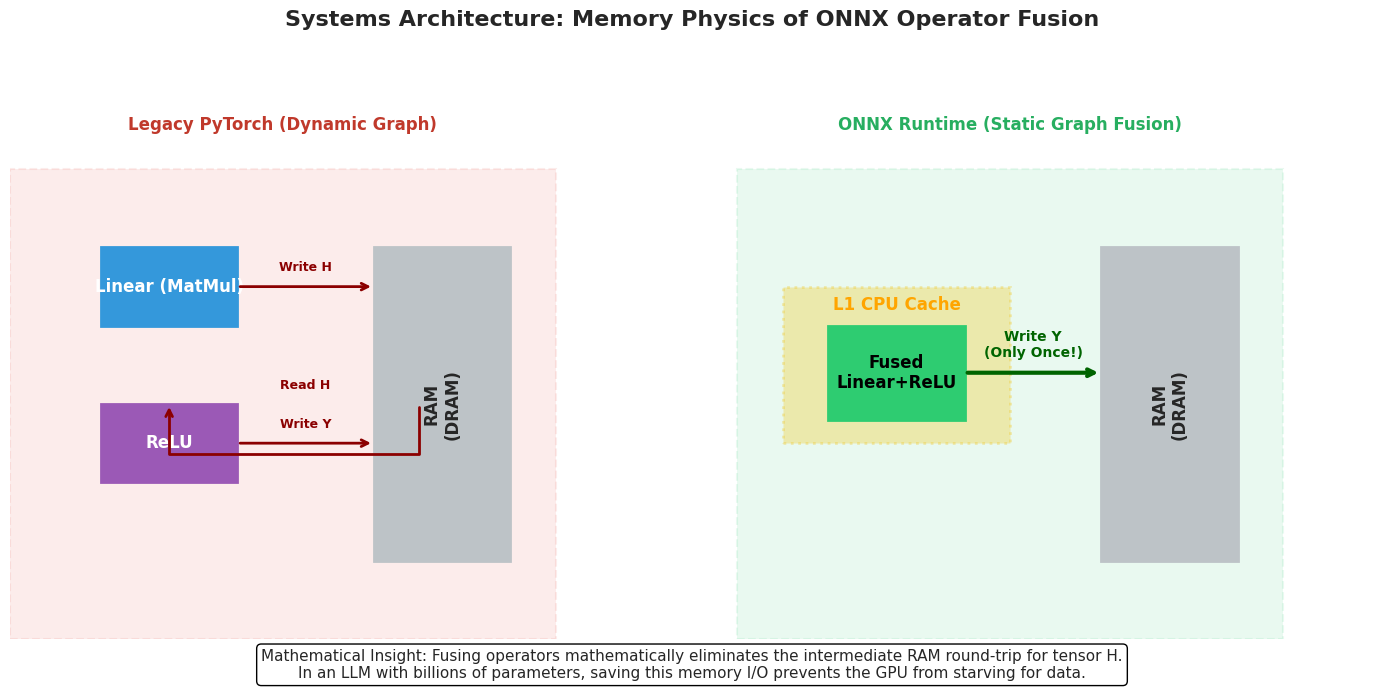

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Systems Architecture: Memory Physics of ONNX Operator Fusion", fontsize=16, fontweight='bold')
ax.axis('off')

# -------------------------------------------------------------------
# LEFT: UNOPTIMIZED DYNAMIC GRAPH (Legacy PyTorch)
# -------------------------------------------------------------------
ax.text(3, 6.5, "Legacy PyTorch (Dynamic Graph)", ha='center', fontweight='bold', fontsize=12, color='#c0392b')
ax.add_patch(patches.Rectangle((0, 0), 6, 6, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', lw=1.5, ls='--'))

# Memory Box
ax.add_patch(patches.Rectangle((4, 1), 1.5, 4, fill=True, color='#bdc3c7', edgecolor='black', lw=2))
ax.text(4.75, 3, "RAM\n(DRAM)", ha='center', va='center', fontweight='bold', rotation=90)

# Operator 1: MatMul
ax.add_patch(patches.Rectangle((1, 4), 1.5, 1, fill=True, color='#3498db', edgecolor='black', lw=2))
ax.text(1.75, 4.5, "Linear (MatMul)", ha='center', va='center', color='white', fontweight='bold')

# Operator 2: ReLU
ax.add_patch(patches.Rectangle((1, 2), 1.5, 1, fill=True, color='#9b59b6', edgecolor='black', lw=2))
ax.text(1.75, 2.5, "ReLU", ha='center', va='center', color='white', fontweight='bold')

# Data Flow Arrows (The I/O Bottleneck)
ax.annotate("", xy=(4, 4.5), xytext=(2.5, 4.5), arrowprops=dict(arrowstyle="->", lw=2, color="darkred"))
ax.text(3.25, 4.7, "Write H", ha='center', fontsize=9, color='darkred', fontweight='bold')

ax.annotate("", xy=(1.75, 3), xytext=(4.5, 3), arrowprops=dict(arrowstyle="->", connectionstyle="bar,fraction=-0.2", lw=2, color="darkred"))
ax.text(3.25, 3.2, "Read H", ha='center', fontsize=9, color='darkred', fontweight='bold')

ax.annotate("", xy=(4, 2.5), xytext=(2.5, 2.5), arrowprops=dict(arrowstyle="->", lw=2, color="darkred"))
ax.text(3.25, 2.7, "Write Y", ha='center', fontsize=9, color='darkred', fontweight='bold')

# -------------------------------------------------------------------
# RIGHT: OPTIMIZED STATIC GRAPH (ONNX Runtime)
# -------------------------------------------------------------------
ax.text(11, 6.5, "ONNX Runtime (Static Graph Fusion)", ha='center', fontweight='bold', fontsize=12, color='#27ae60')
ax.add_patch(patches.Rectangle((8, 0), 6, 6, fill=True, color='#2ecc71', alpha=0.1, edgecolor='black', lw=1.5, ls='--'))

# Memory Box
ax.add_patch(patches.Rectangle((12, 1), 1.5, 4, fill=True, color='#bdc3c7', edgecolor='black', lw=2))
ax.text(12.75, 3, "RAM\n(DRAM)", ha='center', va='center', fontweight='bold', rotation=90)

# CPU L1 Cache Box (Inside the processing unit)
ax.add_patch(patches.Rectangle((8.5, 2.5), 2.5, 2, fill=True, color='#f1c40f', alpha=0.3, edgecolor='orange', lw=2, ls='dotted'))
ax.text(9.75, 4.2, "L1 CPU Cache", ha='center', fontweight='bold', color='orange')

# FUSED OPERATOR
ax.add_patch(patches.Rectangle((9, 2.8), 1.5, 1.2, fill=True, color='#2ecc71', edgecolor='black', lw=2))
ax.text(9.75, 3.4, "Fused\nLinear+ReLU", ha='center', va='center', color='black', fontweight='bold')

# Optimized Data Flow
ax.annotate("", xy=(12, 3.4), xytext=(10.5, 3.4), arrowprops=dict(arrowstyle="->", lw=3, color="darkgreen"))
ax.text(11.25, 3.6, "Write Y\n(Only Once!)", ha='center', fontsize=10, color='darkgreen', fontweight='bold')

ax.text(7.5, -0.5, "Mathematical Insight: Fusing operators mathematically eliminates the intermediate RAM round-trip for tensor H.\nIn an LLM with billions of parameters, saving this memory I/O prevents the GPU from starving for data.", 
        ha='center', fontsize=11, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

plt.xlim(0, 15)
plt.ylim(0, 7.5)
plt.tight_layout()
plt.show()

*(Insight: Modern hardware (GPUs/CPUs) can perform math far faster than they can read and write data to main memory. By predicting the entire execution graph ahead of time, ONNX Runtime mathematically folds layers together, completing the computation entirely within the ultra-fast L1 cache and bypassing the memory bottleneck entirely.)*

## Real-World Use Case or Analogy

Think of PyTorch vs. ONNX Runtime like **A Custom Restaurant Order vs. An Automated Assembly Line**:

* **PyTorch (The Custom Restaurant):** Every time an inference request arrives, the Python Interpreter (The Waiter) walks to the Matrix Multiplication station, orders the ingredients, waits for them to finish, takes the plate to a holding table (**Main Memory**), walks to the ReLU station, tells them to process the plate, waits, and then brings it to the user. It works, it's highly flexible, but the waiter does an absurd amount of unnecessary walking.
* **ONNX (The Blueprint):** You map out the exact sequence of the recipe into a strict engineering blueprint. You prove that the menu never changes.
* **ONNX Runtime (The Assembly Line):** Using the blueprint, you rip out the holding tables and physically bolt the Matrix Multiplication station directly to the ReLU station. You fire the Python Waiter. When a request comes in, the C++ engine feeds raw ingredients into the front, the food passes instantly between stations without ever touching a holding table (**Operator Fusion / L1 Cache**), and a finished prediction ejects out the back at 10x the speed.